##Contents

0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

# 0. Learning Objectives

*   Application of  **KNN-based Bagging** on a public dataset
*   Found the **Out-of-Bag** error for esembles

#1. Tutorial Details

*   **ML Topic(s) Covered**: Bagging, KNN Classifier
*   **Problem Statement**: The Iris dataset is a classic and well-known dataset in the field of machine learning. It consists of measurements of four features (sepal length, sepal width, petal length, and petal width) of three different species of iris flowers (setosa, versicolor, and virginica).
*   Approximate model training time:5-10 min.

#2. Problem Statement Description

*   **Data Description**: The dataset contains 150 samples, with 50 samples for each species.

    * Sepal Length: Represents the length of the sepal (the outermost whorl of the flower), measured in centimeters.
    * Sepal Width: Indicates the width of the sepal, measured in centimeters.
    * Petal Length: Represents the length of the petal (the inner whorl of the flower), measured in centimeters.
    * Petal Width: Indicates the width of the petal, measured in centimeters.


*   More information is available here: https://archive.ics.uci.edu/dataset/53/iris

# 3. Import Packages

Package version

*   pandas==1.4.4

In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# Scikit-learn (sklearn) contains functions of machine learning models, evaluation metrics, helper functions and datasets
import sklearn

# 4. Load and Prepare the Dataset

In [2]:
#Load the Iris Dataset
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()

# Convert the dataset to a pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


We have 4 features followed by 1 target variable.

In [3]:
#Print the shape of the data
df.shape

(150, 5)


There are 5 columns (4 features and 1 target variable) and 150 rows in the imported data.

In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


*   There is no null value.

Below, let us separate the feature (independent variable) and the target variable (dependent variable) in the data.

In [5]:
features = df.iloc[:, :-1]
predictions = df.iloc[:, -1] #Last column contains the target variable

In [6]:
#Print a fews rows of independent variables
features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
#Print a fews rows of dependent variables
predictions.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Below, let us divided into the training and testing data.

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, predictions, test_size=0.2, random_state=0, shuffle=True)
#20% of the total data is kept as test data

# 5.   Peform Exploratory Data Analysis (EDA)

This has been performed in the earlier tutorials.

# 6.   Model Building: Training and Testing

Let us define a KNN Classifier model to perform the given classification task using Bagging classification.

In [10]:
#Import K Nearest Neighbors Classifier class
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier

# Define the base classifier
base_classifier = KNeighborsClassifier(n_neighbors=5)

# Define the bagging classifier
model = BaggingClassifier(base_classifier, n_estimators=10, oob_score=True, random_state=42)

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

# 7.   Result and Interpretation

In [11]:
from sklearn.metrics import f1_score, confusion_matrix


# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, average='weighted')
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Calculate the OOB error
oob_error = 1 - model.oob_score_
print("OOB Error:", oob_error)


# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, average='weighted')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.95
Train confusion matrix: 
 [[39  0  0]
 [ 0 33  4]
 [ 0  2 42]]
OOB Error: 0.050000000000000044
Test F1 score:  0.967
Test confusion matrix: 
 [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


# 8. Conclusion

A KNN classifier has been trained with 10 bagging estimators for the iris dataset.

# 9.   Try it yourself excercise


*   **Problem Statement**: Perform KNN-based classification to predict the age of the abalone using the available data. In this use bagging ensemble strategy.

*   **Task**: Abalone is an endangered shellfish. The goal of the dataset is to predict the age of the abalone (in years) based on the other attributes. The number of rings in the shell of an abalone is a good indicator of its age, and is typically determined through a tedious process of cutting the shell and counting the rings. The dataset provides a more efficient way of estimating the age of abalone using non-invasive measurements.

    *   Number of Instances: 4,177
    *   Number of Attributes: 8
    *   Attribute Information:
        *   Sex: nominal - M, F, and I (infant)
        *   Length: continuous - longest shell measurement (in mm)
        *   Diameter: continuous - perpendicular to length (in mm)
        *   Height: continuous - with meat in shell (in mm)
        *   Whole weight: continuous - whole abalone (in grams)
        *   Shucked weight: continuous - weight of meat (in grams)
        *   Viscera weight: continuous - gut weight (after bleeding) (in grams)
        *   Shell weight: continuous - after being dried (in grams)
        *   Rings: integer - +1.5 gives the age in years (the target variable)


*  **Source**:  https://archive.ics.uci.edu/ml/datasets/abalone


In [11]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight", "Rings"]
abalone_df = pd.read_csv(url, header=None, names=columns)
abalone_df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


[]

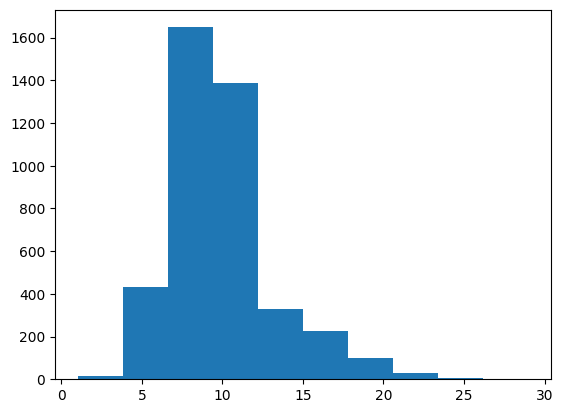

In [12]:
plt.hist(abalone_df['Rings'])
plt.plot()

# 10. Summary

*   To **KNN-based Bagging** on a public dataset
*   Found the **Out-of-Bag** error for esembles
